[FINAL] Elbow K = 438


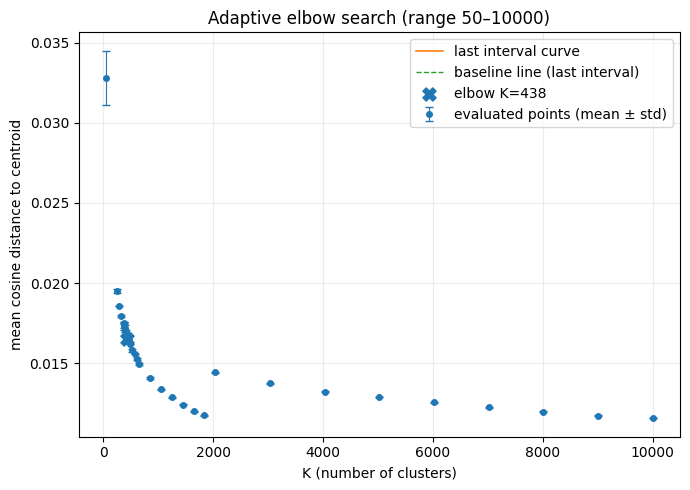

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict, List

# ========== 공통 유틸 ==========
def load_npz(path: str = "/kaggle/working/seq_vec.npz") -> Tuple[List[str], np.ndarray]:
    data = np.load(path, allow_pickle=True)
    return data["seqs"].tolist(), data["X"]

def l2_normalize_rows(X: np.ndarray, eps: float = 1e-9) -> np.ndarray:
    nrm = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.clip(nrm, eps, None)

# ========== 코사인 K-means (풀배치) ==========
def _init_centroids_from_data(Xn: np.ndarray, k: int, rng: np.random.Generator) -> np.ndarray:
    N = Xn.shape[0]
    if k > N:
        raise ValueError("k > N")
    idx = rng.choice(N, size=k, replace=False)
    return Xn[idx].copy()

def _assign(Xn: np.ndarray, C: np.ndarray) -> np.ndarray:
    # argmax dot == 최소 (1 - cos)
    return np.argmax(Xn @ C.T, axis=1)

def _update(Xn: np.ndarray, labels: np.ndarray, k: int, rng: np.random.Generator) -> np.ndarray:
    D = Xn.shape[1]
    C = np.zeros((k, D), dtype=Xn.dtype)
    for c in range(k):
        members = Xn[labels == c]
        if members.size == 0:
            C[c] = Xn[rng.integers(0, Xn.shape[0])]
        else:
            v = members.mean(axis=0)
            n = np.linalg.norm(v)
            C[c] = v / n if n > 0 else v
    return C

def cosine_kmeans_full(Xn: np.ndarray, k: int, max_iter: int = 30, seed: int = 42, tol: float = 1e-4) -> Tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    C = _init_centroids_from_data(Xn, k, rng)
    for _ in range(max_iter):
        labels = _assign(Xn, C)
        C_new = _update(Xn, labels, k, rng)
        shift = np.linalg.norm(C_new - C, axis=1).max()
        C = C_new
        if shift < tol:
            break
    return labels, C

# ========== 코사인 K-means (미니배치 근사) ==========
def cosine_kmeans_minibatch(
    Xn: np.ndarray,
    k: int,
    batch_size: int = 8192,
    epochs: int = 2,
    seed: int = 42,
) -> np.ndarray:
    """
    간단한 미니배치 K-means: 배치마다 할당→배치 평균으로 가중 업데이트.
    센트로이드는 계속 L2 정규화해 코사인 공간 유지.
    반환: C (k,D)  ; labels는 비용 계산 때 샘플 위에서만 필요하므로 생략
    """
    rng = np.random.default_rng(seed)
    N, D = Xn.shape
    C = _init_centroids_from_data(Xn, k, rng)

    for _ in range(epochs):
        # 셔플된 인덱스 스트림
        for start in range(0, N, batch_size):
            end = min(N, start + batch_size)
            B = Xn[start:end]
            if B.size == 0:
                continue
            # 할당
            lbl = np.argmax(B @ C.T, axis=1)
            # 각 클러스터 배치 평균으로 이동 (가중치: 배치 내 빈도)
            for c in range(k):
                idx = np.where(lbl == c)[0]
                if idx.size == 0:
                    continue
                v = B[idx].mean(axis=0)
                n = np.linalg.norm(v)
                v = v / n if n > 0 else v
                # 간단한 이동(EMA 아님): 바로 배치 평균로 덮어쓰기
                C[c] = v
    return C

# ========== 비용(평균 1 - cos) ==========
def mean_cosine_distance(Xn: np.ndarray, labels: np.ndarray, C: np.ndarray) -> float:
    sims = np.einsum("nd,nd->n", Xn, C[labels])
    return float(1.0 - sims.mean())

def mean_cosine_distance_sample(Xn: np.ndarray, C: np.ndarray, sample_idx: np.ndarray) -> float:
    B = Xn[sample_idx]
    lbl = np.argmax(B @ C.T, axis=1)
    sims = np.einsum("nd,nd->n", B, C[lbl])
    return float(1.0 - sims.mean())

# ========== K별 평가 (자동 모드 선택 + 캐시) ==========
def evaluate_K_auto(
    Xn: np.ndarray,
    K: int,
    n_init: int,
    seed_base: int,
    full_cutoff: int,
    max_iter_full: int,
    mb_batch: int,
    mb_epochs: int,
    sample_for_cost: int,
    rng_global: np.random.Generator,
) -> Tuple[float, float]:
    """
    K <= full_cutoff: 풀배치 여러 번 → 정확한 비용(전량)
    K >  full_cutoff: 미니배치 여러 번 → 비용은 50k 샘플 근사
    return mean_cost, std_cost
    """
    costs = []
    # 비용 샘플 (근사 모드에서만 사용)
    if sample_for_cost > 0:
        subN = min(sample_for_cost, Xn.shape[0])
        sample_idx = rng_global.choice(Xn.shape[0], size=subN, replace=False)
    else:
        sample_idx = None

    for rep in range(n_init):
        seed = seed_base + 1000 * K + rep
        if K <= full_cutoff:
            labels, C = cosine_kmeans_full(Xn, K, max_iter=max_iter_full, seed=seed)
            cost = mean_cosine_distance(Xn, labels, C)
        else:
            C = cosine_kmeans_minibatch(Xn, K, batch_size=mb_batch, epochs=mb_epochs, seed=seed)
            if sample_idx is None:
                # 안전장치: 혹시 sample_for_cost=0이면 전량(비권장)
                lbl = np.argmax(Xn @ C.T, axis=1)
                cost = mean_cosine_distance(Xn, lbl, C)
            else:
                cost = mean_cosine_distance_sample(Xn, C, sample_idx)
        costs.append(cost)

    costs = np.array(costs, dtype=float)
    return float(costs.mean()), float(costs.std(ddof=1) if len(costs) > 1 else 0.0)

# ========== Kneedle (직선 대비 최대 이탈) ==========
def kneedle_pick(K_list: List[int], C_mean: np.ndarray):
    K = np.asarray(K_list, dtype=float)
    C = np.asarray(C_mean, dtype=float)
    k0, k1 = K[0], K[-1]
    c0, c1 = C[0], C[-1]
    C_line = c0 + ((K - k0) / (k1 - k0)) * (c1 - c0)
    dist = np.abs(C - C_line)
    idx = int(np.argmax(dist))
    return int(K[idx]), idx, C_line, dist

# ========== 10등분 줌인 ==========
def integer_linspace(a: int, b: int, num: int) -> List[int]:
    if a == b:
        return [a]
    xs = np.linspace(a, b, num=num)
    ks = sorted(set(int(round(v)) for v in xs))
    ks = [k for k in ks if k >= 2]
    if len(ks) < 3 and (b - a) >= 2:
        ks = list(range(a, b + 1))
    return ks

def refine_elbow_adaptive(
    Xn: np.ndarray,
    K_min: int,
    K_max: int,
    num_refine: int,
    n_init: int,
    seed_base: int,
    full_cutoff: int,
    max_iter_full: int,
    mb_batch: int,
    mb_epochs: int,
    sample_for_cost: int,
):
    assert K_max > K_min >= 2
    rng = np.random.default_rng(42)
    cache: Dict[int, Tuple[float, float]] = {}
    allK, allM, allS = [], [], []
    history = []

    left, right = K_min, K_max
    for step in range(num_refine + 1):
        K_list = integer_linspace(left, right, num=11)
        if len(K_list) < 3:
            break

        C_mean, C_std = [], []
        for K in K_list:
            if K in cache:
                m, s = cache[K]
            else:
                m, s = evaluate_K_auto(
                    Xn, K, n_init, seed_base,
                    full_cutoff, max_iter_full,
                    mb_batch, mb_epochs,
                    sample_for_cost, rng
                )
                cache[K] = (m, s)
            C_mean.append(m); C_std.append(s)

        C_mean = np.array(C_mean, float)
        C_std  = np.array(C_std,  float)
        elbow_k, elbow_idx, C_line, dist = kneedle_pick(K_list, C_mean)

        # 기록
        for K, m, s in zip(K_list, C_mean, C_std):
            if K not in allK:
                allK.append(K); allM.append(m); allS.append(s)
        history.append({
            "interval": (left, right),
            "K_list": K_list, "C_mean": C_mean, "C_std": C_std,
            "elbow_k": elbow_k, "elbow_idx": elbow_idx,
            "C_line": C_line, "dist": dist
        })

        # 다음 구간(엘보의 좌/우 이웃으로 zoom-in)
        if step == num_refine:
            break
        if elbow_idx == 0:
            new_left, new_right = K_list[0], K_list[1]
        elif elbow_idx == len(K_list) - 1:
            new_left, new_right = K_list[-2], K_list[-1]
        else:
            new_left, new_right = K_list[elbow_idx - 1], K_list[elbow_idx + 1]
        left, right = max(2, new_left), max(new_left + 1, new_right)
        if right - left <= 2:
            break

    order = np.argsort(allK)
    allK = [allK[i] for i in order]
    allM = np.array([allM[i] for i in order], float)
    allS = np.array([allS[i] for i in order], float)
    return {"final_elbow_k": history[-1]["elbow_k"], "allK": allK, "allM": allM, "allS": allS, "history": history}

# ========== 메인 ==========
def main():
    # ---- 파일 로드 & 정규화 1회 ----
    seqs, X = load_npz("/kaggle/input/latent-vec-calculation/seq_vec.npz")
    Xn = l2_normalize_rows(X).astype(np.float32)  # 메모리 절약 겸 속도

    # ---- 요청한 탐색 범위 ----
    K_MIN, K_MAX = 50, min(10000, Xn.shape[0] - 1)

    # ---- 대용량 튜닝 파라미터 ----
    NUM_REFINE     = 4          # 10등분 반복 횟수 (총 5단계)
    N_INIT         = 2          # 각 K에서 반복 수 (큰 K 많으니 낮춤)
    FULL_CUTOFF    = 2000        # 이 이하면 풀배치로 정확 계산
    MAX_ITER_FULL  = 25         # 풀배치 반복 수
    MB_BATCH       = 8192       # 미니배치 크기
    MB_EPOCHS      = 2          # 미니배치 epoch 수
    SAMPLE_FOR_COST= 50000      # 큰 K에서 비용 평가 샘플 크기

    result = refine_elbow_adaptive(
        Xn,
        K_min=K_MIN, K_max=K_MAX,
        num_refine=NUM_REFINE,
        n_init=N_INIT,
        seed_base=42,
        full_cutoff=FULL_CUTOFF,
        max_iter_full=MAX_ITER_FULL,
        mb_batch=MB_BATCH,
        mb_epochs=MB_EPOCHS,
        sample_for_cost=SAMPLE_FOR_COST,
    )
    elbow_k = result["final_elbow_k"]
    print(f"[FINAL] Elbow K = {elbow_k}")

    # ---- 600 dpi 시각화 (마지막 단계 강조) ----
    allK, allM, allS = result["allK"], result["allM"], result["allS"]
    fig, ax = plt.subplots(figsize=(7,5))
    ax.errorbar(allK, allM, yerr=allS, fmt="o", capsize=3, markersize=4, linewidth=0.8,
                label="evaluated points (mean ± std)")

    last = result["history"][-1]
    Kl, Ml, Sl, Lline, eidx, ek = last["K_list"], last["C_mean"], last["C_std"], last["C_line"], last["elbow_idx"], last["elbow_k"]
    ax.plot(Kl, Ml, "-", linewidth=1.2, label=f"last interval curve")
    ax.plot(Kl, Lline, "--", linewidth=1.0, label="baseline line (last interval)")
    ax.scatter([Kl[eidx]], [Ml[eidx]], s=90, marker="X", label=f"elbow K={ek}")

    ax.set_xlabel("K (number of clusters)")
    ax.set_ylabel("mean cosine distance to centroid")
    ax.set_title(f"Adaptive elbow search (range {K_MIN}–{K_MAX})")
    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig("/kaggle/working/elbow_adaptive_full_870k.png", dpi=600)
    # plt.show()

if __name__ == "__main__":
    main()
